## Examples: Heterogeneous ensemble methods

#### In this train, we'll dive into heterogeneous ensemble methods, combining various model types to enhance prediction strength with a focus on implementing voting and stacking techniques.

### Learning Objectives
#### By the end of this train, you should be able to:
##### - Combine diverse models for predictions.
##### - Implement vofing and stacking strategies.

### Heterogeneous ensembles

#### This type of ensemble consists of **different types of models**, so we can add pretty much any regression model we want.

#### Here we investigate two ways of combining models which are different in nature: **voting** and **stacking**

### 1. Training the individual models

#### Let's start by training different individual machine learning models on the same data.

#### We'll train a `Linear regression`, a `Decision tree`, and an `SVR` (i.e. support vector machine regression - we'll explore this model in greater detail in later tutorials) model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error

In [2]:
df = pd.read_csv("https://github.com/Explore-AI/Public-Data/blob/master/house_price_by_area.csv?raw=true")
df.head()

,LotArea,SalePrice
0,138,1204000
1,145,1274000
2,152,1673000
3,152,1232000
4,152,1195600


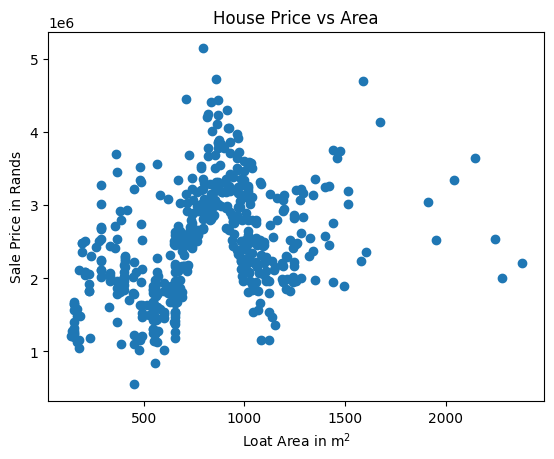

In [3]:
X = df['LotArea']
y = df['SalePrice']

plt.scatter(X,y)
plt.title('House Price vs Area')
plt.xlabel('Loat Area in m$^2$')
plt.ylabel('Sale Price in Rands')
plt.show()

In [5]:
type(y)

pandas.core.series.Series

### Pre-processing

In [10]:
# initialise the scalers
X_scaler = StandardScaler()
y_scaler = StandardScaler()

# Normalise x and y
X_scaled = X_scaler.fit_transform(np.array(X)[:,np.newaxis])
y_scaled = y_scaler.fit_transform(np.array(y)[:, np.newaxis])

# set test size to 20% of training data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=6)

### a) Linear Regression

In [11]:
# instantiate Linear Regression model
lin_reg = LinearRegression()

lin_reg.fit(X_train, y_train)

LinearRegression()

RMSE:  0.9597285404528205


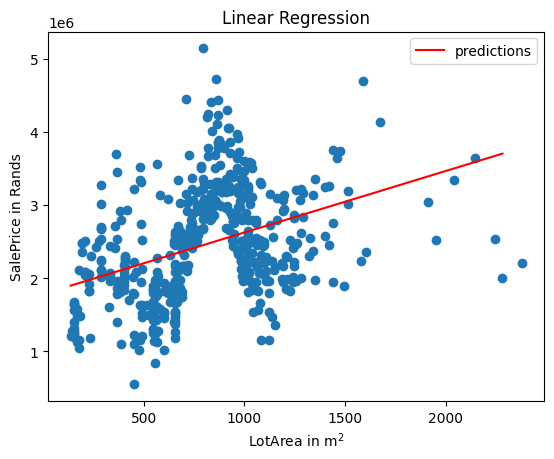

In [12]:
y_pred = lin_reg.predict(X_test)
print("RMSE: ", np.sqrt(mean_squared_error(y_test, y_pred)))

# Plot the Linear Regression prediction line over data
x_domain = np.linspace(min(X_train), max(X_train), 100)

y_pred_rescaled = y_scaler.inverse_transform(lin_reg.predict(x_domain))
x_rescaled = X_scaler.inverse_transform(x_domain)

plt.figure()
plt.scatter(X, y)
plt.plot(x_rescaled, y_pred_rescaled, color='red', label='predictions')
plt.xlabel('LotArea in m$^2$')
plt.ylabel('SalePrice in Rands')
plt.title('Linear Regression')
plt.legend()
plt.show()

### b) Decision tree

In [54]:
# instantiate regression tree model
regr_tree = DecisionTreeRegressor(max_depth=3)

regr_tree.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=3)

RMSE:  0.8155834161717601


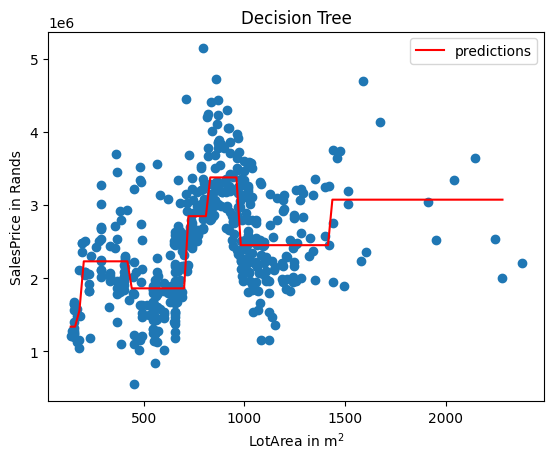

In [55]:
y_pred = regr_tree.predict(X_test)
print("RMSE: ", np.sqrt(mean_squared_error(y_test, y_pred)))

# Plot the regression tree prediction line over data
x_domain = np.linspace(min(X_train), max(X_train), 100)

y_pred_rescaled = y_scaler.inverse_transform(regr_tree.predict(x_domain).reshape(-1, 1))
x_rescaled = X_scaler.inverse_transform(x_domain)

plt.figure()
plt.scatter(X, y)
plt.plot(x_rescaled, y_pred_rescaled, color='red', label='predictions')
plt.xlabel('LotArea in m$^2$')
plt.ylabel('SalesPrice in Rands')
plt.title('Decision Tree')
plt.legend()
plt.show()

### c) Support vector regression

In [56]:
# instantiate support vector regresion model
sv_reg = SVR(kernel='rbf', gamma='auto')

sv_reg.fit(X_train, y_train[:, 0])

SVR(gamma='auto')

RMSE:  0.7823020808791088


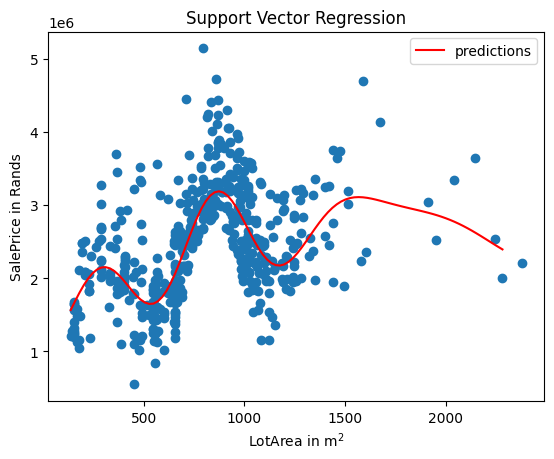

In [57]:
y_pred = sv_reg.predict(X_test)
print("RMSE: ", np.sqrt(mean_squared_error(y_test, y_pred)))

# Plot the SVR prediction line over data
x_domain = np.linspace(min(X_train), max(X_train), 100)

y_pred_rescaled = y_scaler.inverse_transform(sv_reg.predict(x_domain).reshape(-1, 1))
x_rescaled = X_scaler.inverse_transform(x_domain)

plt.figure()
plt.scatter(X, y)
plt.plot(x_rescaled, y_pred_rescaled, color='red', label='predictions')
plt.xlabel('LotArea in m$^2$')
plt.ylabel('SalePrice in Rands')
plt.title('Support Vector Regression')
plt.legend()
plt.show()

### 2. Heterogeneous ensembling in Python

#### a) Voting

In [28]:
# Importing the VotingRegressor class from sklearn
from sklearn.ensemble import VotingRegressor

#### Building the voting ensemble

In [58]:
# Define the models which we'll include in our ensemble
# We pass a list of tuples, which each have a string identifier for the 
# model (arbitrary choice), along with the actual instantiated sklearn model
models = [('LR', lin_reg), ('DT', regr_tree), ('SVR', sv_reg)]

# Specify weights for weighted model averaging
model_weightings = np.array([0.1,0.3,0.6])
v_reg = VotingRegressor(estimators=models, weights=model_weightings)

#### Training the voting ensemble

In [59]:
v_reg.fit(X_train, y_train[:, 0])

VotingRegressor(estimators=[('LR', LinearRegression()),
                            ('DT', DecisionTreeRegressor(max_depth=3)),
                            ('SVR', SVR(gamma='auto'))],
                weights=array([0.1, 0.3, 0.6]))

#### Checking the performance of the voting ensemble

RMSE:  0.7804899566713737


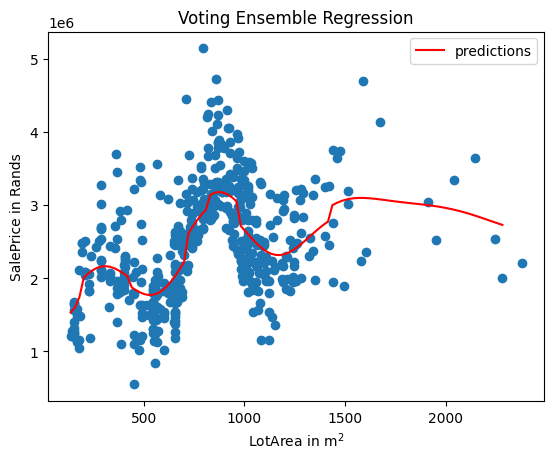

In [60]:
y_pred = v_reg.predict(X_test)
print("RMSE: ", np.sqrt(mean_squared_error(y_test, y_pred)))

# Plot the voting regression prediction line over data
x_domain = np.linspace(min(X_train), max(X_train), 100)

y_pred_rescaled = y_scaler.inverse_transform(v_reg.predict(x_domain).reshape(-1, 1))
x_rescaled = X_scaler.inverse_transform(x_domain)

plt.figure()
plt.scatter(X, y)
plt.plot(x_rescaled, y_pred_rescaled, color='red', label='predictions')
plt.xlabel('LotArea in m$^2$')
plt.ylabel('SalePrice in Rands')
plt.title('Voting Ensemble Regression')
plt.legend()
plt.show()

#### b) Stacking

In [61]:
from sklearn.ensemble import StackingRegressor

#### Building the stacking ensemble

In [62]:
# For clarity, we declare our model list again here
models = [('LR', lin_reg), ('DT', regr_tree), ('SVR', sv_reg)]

# Instead of choosing model weightings, we now declare the meta-learner model for out stacking ensemble
meta_learner_reg = LinearRegression()

s_reg = StackingRegressor(estimators=models, final_estimator=meta_learner_reg)

#### Training the stacking ensemble

In [63]:
s_reg.fit(X_train, y_train[:,0])

StackingRegressor(estimators=[('LR', LinearRegression()),
                              ('DT', DecisionTreeRegressor(max_depth=3)),
                              ('SVR', SVR(gamma='auto'))],
                  final_estimator=LinearRegression())

#### Checking the performance of the voting ensemble

RMSE:  0.7778568350749012


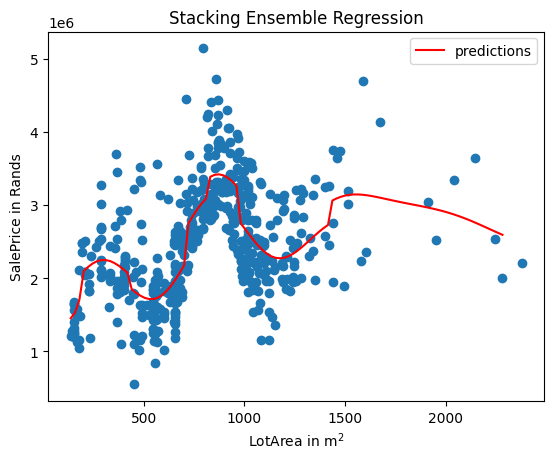

In [67]:
y_pred = s_reg.predict(X_test)
print("RMSE: ", np.sqrt(mean_squared_error(y_test, y_pred)))

# Plot the stacking regression prediction line over data
x_domain = np.linspace(min(X_train), max(X_train), 100)

y_pred_rescaled = y_scaler.inverse_transform(s_reg.predict(x_domain).reshape(-1, 1))
x_rescaled = X_scaler.inverse_transform(x_domain)

plt.figure()
plt.scatter(X, y)
plt.plot(x_rescaled, y_pred_rescaled, color='red', label='predictions')
plt.xlabel('LotArea in m$^2$')
plt.ylabel('SalePrice in Rands')
plt.title('Stacking Ensemble Regression')
plt.legend()
plt.show()